In [1]:
import pandas as pd
import numpy as np
import geopandas as gpd
import matplotlib.pyplot as plt
from shapely.ops import split
import cartopy.io.shapereader as shpreader
from shapely.affinity import scale
from pyfonts import load_google_font

# Data

In [2]:
# Load data
data = pd.read_csv("data.csv")

In [3]:
# Check data types
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4 entries, 0 to 3
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Year        4 non-null      int64  
 1   Population  4 non-null      float64
dtypes: float64(1), int64(1)
memory usage: 196.0 bytes


In [4]:
data

,Year,Population
0,1800,0.2000
1,1830,0.1667
2,1860,0.1428
3,1890,0.1111


In [5]:
# Calculate factors for affine transformations
data["Scale"] = np.sqrt(data["Population"])

# Map

In [6]:
# Load geojson
usa = gpd.read_file("usa.geojson")

In [7]:
# Check projection
usa.crs

<Geographic 2D CRS: EPSG:4326>
Name: WGS 84
Axis Info [ellipsoidal]:
- Lat[north]: Geodetic latitude (degree)
- Lon[east]: Geodetic longitude (degree)
Area of Use:
- name: World.
- bounds: (-180.0, -90.0, 180.0, 90.0)
Datum: World Geodetic System 1984 ensemble
- Ellipsoid: WGS 84
- Prime Meridian: Greenwich

In [8]:
# Check data types
usa.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1 entries, 0 to 0
Data columns (total 10 columns):
 #   Column                    Non-Null Count  Dtype   
---  ------                    --------------  -----   
 0   geo_point_2d              1 non-null      object  
 1   iso3                      1 non-null      object  
 2   status                    1 non-null      object  
 3   color_code                1 non-null      object  
 4   name                      1 non-null      object  
 5   continent                 1 non-null      object  
 6   region                    1 non-null      object  
 7   iso_3166_1_alpha_2_codes  1 non-null      object  
 8   french_short              1 non-null      object  
 9   geometry                  1 non-null      geometry
dtypes: geometry(1), object(9)
memory usage: 212.0+ bytes


In [9]:
usa

,geo_point_2d,iso3,status,color_code,name,continent,region,iso_3166_1_alpha_2_codes,french_short,geometry
0,"{'lon': -112.4917507593385, 'lat': 45.69574378...",USA,Member State,USA,United States of America,Americas,Northern America,US,États-Unis d'Amérique,"MULTIPOLYGON (((-155.00558 19.32888, -155.1453..."


## USA split

In [10]:
# Select first row
us = usa.iloc[0] 

# Extract geometry
poly = us.geometry  

# Extract polygons 
split_polygons = list(poly.geoms)

# Extract number of polygons
n_splits = len(split_polygons)

# Remove USA
us1 = usa[usa["iso3"] != "USA"]

# Create new rows for polygons
split_gdf = gpd.GeoDataFrame(
    {
        "name": ["United States of America"] * n_splits,    
        "iso3": [f"US{i+1}" for i in range(n_splits)],
        "geometry": split_polygons
    },
    crs=usa.crs
)

# Concatenate original gdf with splitted polygons
us2 = pd.concat([us1, split_gdf], ignore_index=True)

# Select relevant columns
us3 = us2[["iso3", "name", "geometry"]]

In [11]:
# Keep only the largest polygon
usa_mainland = us3[us3["iso3"] == "US36"]

In [12]:
# Reproject to EPSG:9311
usa_proj = usa_mainland.to_crs(epsg=9311)

## Great Lakes

In [13]:
# Load lakes shapefile 
lakes_data = shpreader.natural_earth(
    resolution="50m",
    category="physical",
    name="lakes"
)

# Load shapefile data into gdf
lakes = gpd.read_file(lakes_data)

# Reproject to EPSG:9311
lakes = lakes.to_crs(epsg=9311)

# List of lakes
lakes_names = [
    "Lake Superior",
    "Lake Michigan",
    "Lake Huron",
    "Lake Erie",
    "Lake Ontario",    
]

# Filter for list of Great Lakes
great_lakes = lakes[lakes["name"].isin(lakes_names)]

In [14]:
# Select relevant columns
great_lakes = great_lakes[["name", "geometry"]]

# Merge of gdfs

In [15]:
gdf = pd.concat([usa_proj, great_lakes])
gdf = gdf[["name", "geometry"]].reset_index(drop=True)

# Titles

In [16]:
title = "PROPORTION OF NEGROES IN THE TOTAL POPULATION OF THE UNITED STATES ."        

subtitle1 = "RAPPORT DES NÈGRES À LA POPULATION TOTATLE DES ETATS UNIS ."
            
subtitle2 = "DONE BY ATLANTA UNIVERSITY ."

# Custom font

In [17]:
# Custom font
font_bold = load_google_font("Public Sans", weight="bold")
font_black = load_google_font("Public Sans", weight="black")

# Plot

[Affine transformations](https://shapely.readthedocs.io/en/latest/manual.html#affine-transformations)

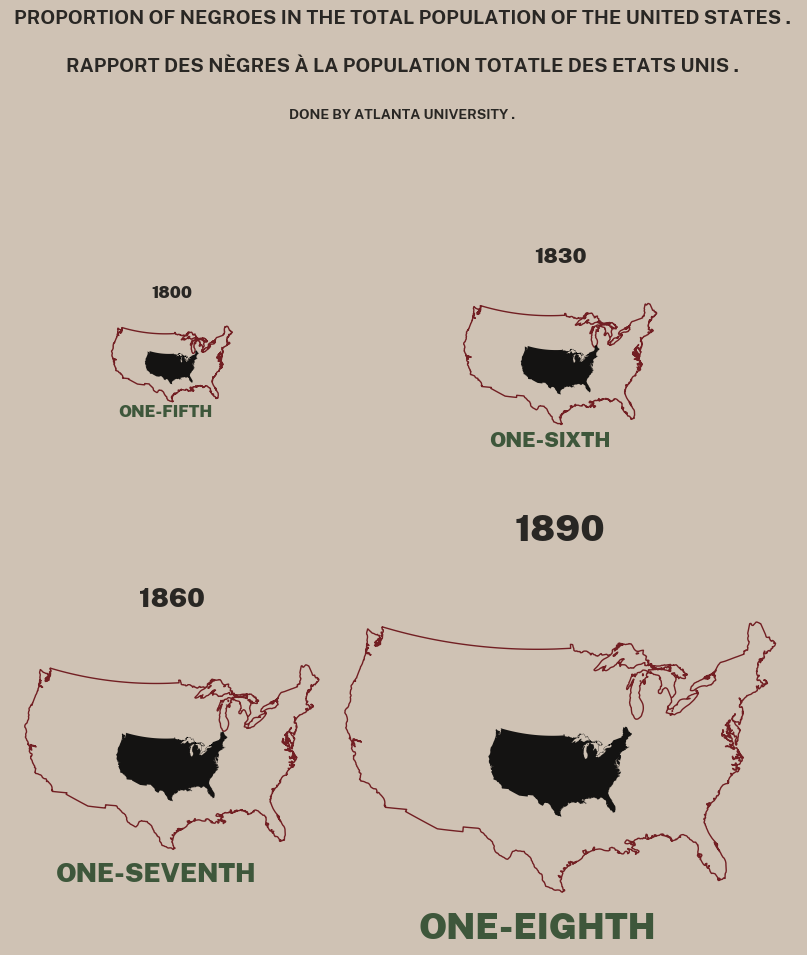

In [18]:
# Prepare data for plotting
scales = data["Scale"].round(4).tolist()
titles = data["Year"].tolist()
ratios = ["ONE-FIFTH", "ONE-SIXTH", "ONE-SEVENTH", "ONE-EIGHTH"]
font_sizes = [12, 15, 19, 26]

# Create figure
fig, axes = plt.subplots(nrows=2, ncols=2, figsize=(8, 9.5), facecolor="#cfc2b4")
plt.subplots_adjust(left=0.01, right=0.90, bottom=0.01, top=0.8, hspace=0.1)
axes = axes.flatten()

# Calculate shared origin for outer and inner maps
minx, miny, maxx, maxy = gdf.total_bounds
origin = ((minx + maxx) / 2, (miny + maxy) / 1.5)

for ax, s, t, fs, r in zip(axes, scales, titles, font_sizes, ratios):   

    # Expansion factors for the axes
    bbox = axes[0].get_position()
    axes[0].set_position(bbox.expanded(0.8, 0.8))

    bbox = axes[1].get_position()
    axes[1].set_position(bbox.expanded(0.9, 0.9))

    bbox = axes[2].get_position()
    axes[2].set_position(bbox.expanded(1, 1))

    bbox = axes[3].get_position()
    axes[3].set_position(bbox.expanded(1.1, 1.1))
    
    # Plot outer map
    gdf.plot(ax=ax, color="#cfc2b4", ec="#721f23")    

    # Scaled geometry of inner maps
    scaled_usa = usa_proj.geometry.apply(
        lambda geom: scale(geom, xfact=s, yfact=s, origin=origin)
    )

    scaled_lakes = great_lakes.geometry.apply(
        lambda geom: scale(geom, xfact=s, yfact=s, origin=origin)
    )

    # Plot inner maps 
    scaled_usa.plot(ax=ax, color="black", alpha=0.9)
    scaled_lakes.plot(ax=ax, color="#cfc2b4", ec="black", lw=0.2)

    # Add title to each subplot
    ax.set_title(t, y=1.2, font=font_black, fontsize=fs, alpha=0.8)    

    # Add text annotation below the subplots
    ax.text(0.2, -2.5e6, r, font=font_black, fontsize=fs, color="#002a08", alpha=0.7, ha="center", va="center")

    # Remove axis
    ax.axis("off")
    
# Add titles
fig.text(0.5, 0.97, s=title, font=font_bold, size=14, alpha=0.8, ha="center")
fig.text(0.5, 0.92, s=subtitle1, font=font_bold, size=14, alpha=0.8, ha="center")
fig.text(0.5, 0.87, s=subtitle2, font=font_bold, size=10, alpha=0.8, ha="center")
    
plt.show()

#plt.savefig("plate42.jpg")

In [19]:
import matplotlib.image as mpimg
from PIL import Image

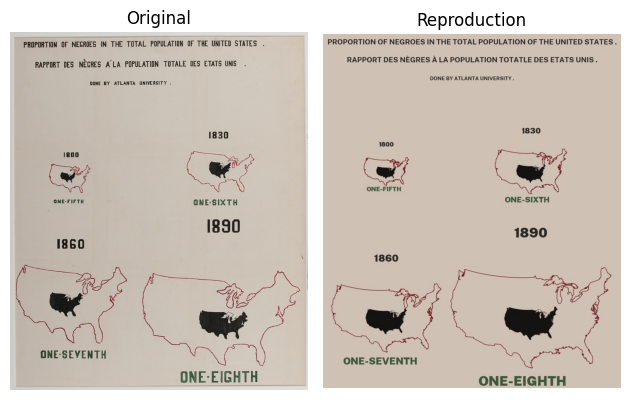

In [20]:
# Load images 
image1 = Image.open("original-plate-42.jpg")
image2 = Image.open("plate42.jpg")

# Convert to numpy arrays
images = [np.array(image1), np.array(image2)]
titles = ["Original", "Reproduction"]

# Create a figure with two subplots
fig, axes = plt.subplots(1, 2)

# Loop through axes, images, and titles
for ax, img, title in zip(axes, images, titles):
    ax.imshow(img)
    ax.axis("off")
    ax.set_title(title)

# Adjust the layout and show
plt.tight_layout()
plt.show()

# Save the combined figure 
#plt.savefig("plate42sidebyside.png", dpi=300)